# 문제 1 — 벡터 연산 모듈 (내적·외적·정사영·rank)

로봇의 좌표 변환은 결국 **벡터 연산**의 조합입니다. 이 노트북에서는
내적·사이각·정규화·정사영·반대칭행렬(외적)·평면 법선·rank 를
`np.linalg` 없이 직접 구현하고, 각각을 검증합니다.

완성한 함수는 `src/vectors.py` 에 채워 넣어 문제 2 이후에서 재사용합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 1-1 | 내적과 사이각을 구하고 **손계산 값과 일치**하는지 검증 | `dot`, `norm`, `angle_between` |
| 1-2 | 정규화 함수를 만들고 **영벡터를 넣으면 어떻게 되는지 직접 실행해 기록**한 뒤 처리 방식을 정해 구현 | `normalize` |
| 1-3 | 정사영을 구현하고 ① 남는 성분이 수직인지 ② 두 성분의 합이 원래 벡터인지 검증 | `project`, `reject` |
| 1-4 | 외적을 **반대칭행렬 곱**으로 구현하고 `np.cross` 와 비교, 반대칭성 검증 | `skew`, `cross` |
| 1-5 | 세 점이 만드는 평면의 **단위 법선** | `plane_normal` |
| 1-6 | (2,1,0), (1,3,1), (3,4,1) 의 rank 를 구하고 **왜 3 이 아닌지** 설명, 행렬식과 일관성 확인 | `row_echelon`, `rank`, `det` |

> **규약**
> - 난수는 `np.random.default_rng(42)` 로 고정합니다.
> - 수치 비교는 부동소수점 오차를 고려해 `np.allclose` / `np.isclose` 로 합니다 (허용오차는 기본값).
> - `np.linalg` 는 **검산용으로만** 쓰고, 쓸 때마다 주석으로 검산임을 밝힙니다.
> - 각 문항은 **(1) 설명 마크다운 → (2) 코드 → (3) 검증** 순서를 지킵니다.
> - `# --- 검증 ---` 셀은 **제공된 코드**입니다. 수정하지 말고, 그 셀이 참조하는 변수 이름을
>   TODO 셀에서 그대로 만들어 주세요. 검증 셀이 전부 `[PASS]` 가 되는 것이 제출 조건입니다.

## 핵심 계산 풀이

학습용 손글씨풍 계산 정리임. 내적의 입력 a,b와 정사영의 입력 u,v를 구분함. 그림의 0은 정확한 산술값이며, 코드 출력의 미세한 차이는 부동소수점 반올림 오차임.

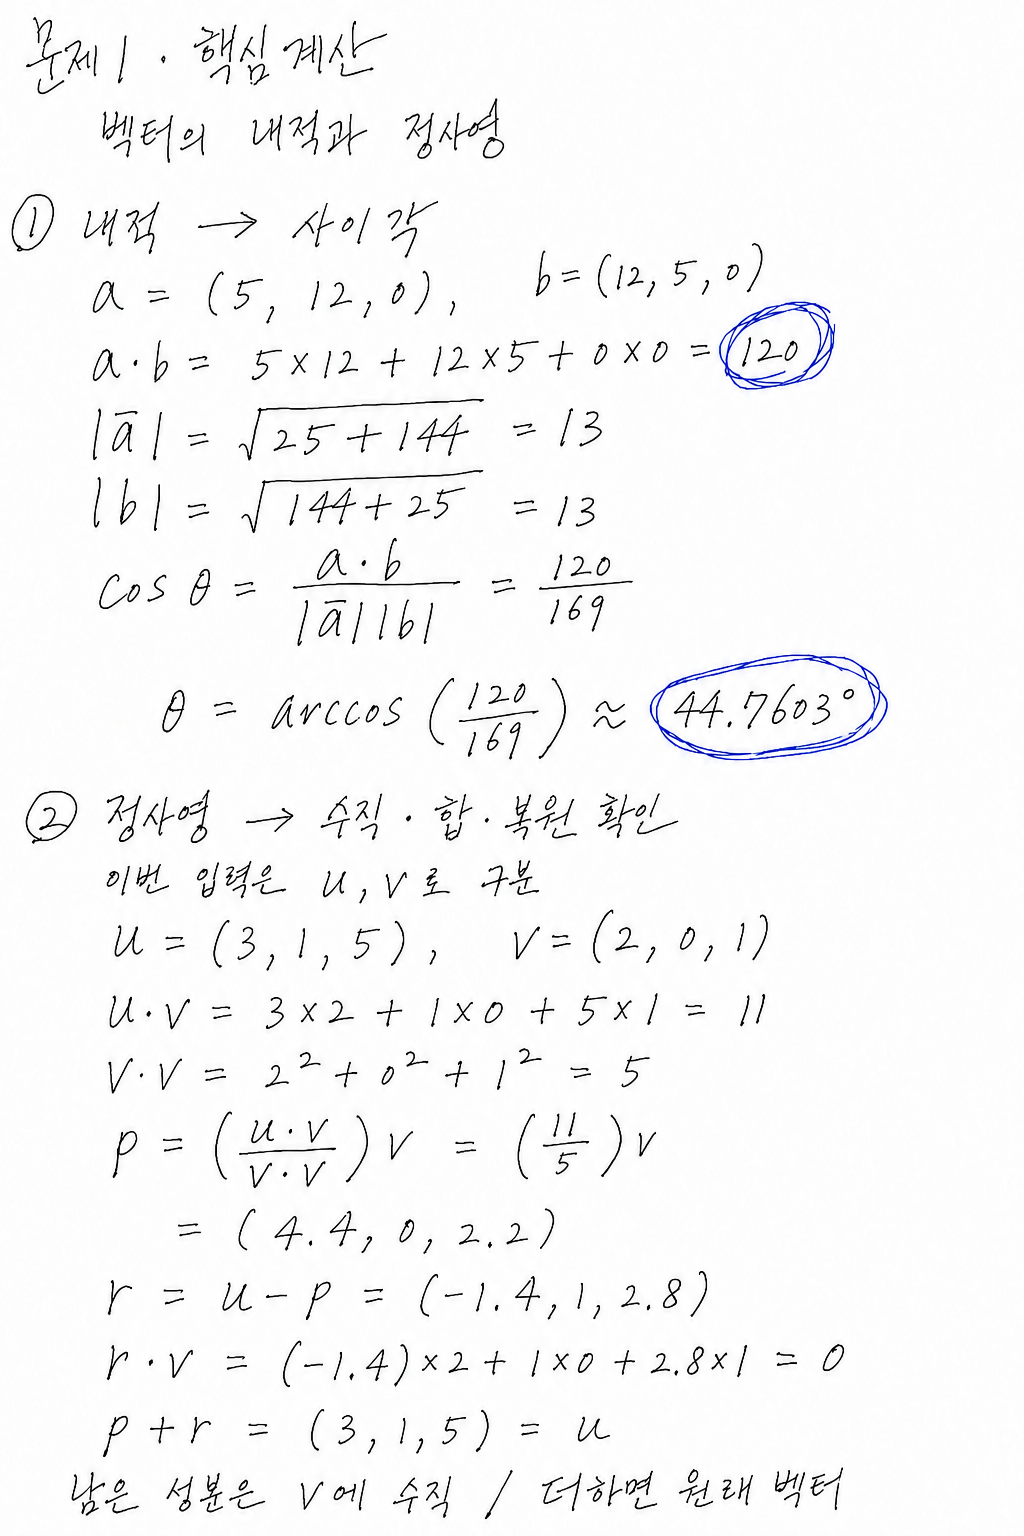

[계산 그림 PNG 원본](../images/handwritten_math/01_vectors.png)


In [1]:
import sys
print("실행 Python:", sys.executable)
print("가상환경 사용:", sys.prefix != sys.base_prefix)


실행 Python: /home/chsjh/.venvs/physicalai-lv1-math/bin/python
가상환경 사용: True


In [2]:
import sys
from pathlib import Path

import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import (angle_between, cross, det, dot, norm, normalize,
                         plane_normal, project, rank, reject, row_echelon, skew)

rng = np.random.default_rng(42)          # 시드 고정
np.set_printoptions(precision=6, suppress=True)


def check(label, condition):
    """검증 셀에서 쓰는 통과/실패 출력 헬퍼. (그대로 쓰면 됩니다)"""
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("NumPy", np.__version__)

NumPy 2.2.6


## 1-1. 내적과 사이각

내적의 정의는 두 가지이며 서로 같습니다.

$$\mathbf{a}\cdot\mathbf{b}=\sum_i a_i b_i = |\mathbf{a}||\mathbf{b}|\cos\theta$$

두 번째 식을 $\theta$ 에 대해 풀면 사이각이 나옵니다.

검증하기 쉽도록 **손으로 계산되는 값**을 고릅니다.
$\mathbf{a}=(5,12,0)$, $\mathbf{b}=(12,5,0)$ 이면 $|\mathbf{a}|=|\mathbf{b}|=13$ 이므로
내적과 $\cos\theta$, 사이각을 종이에서 먼저 구한 뒤 코드 결과와 비교하세요.

**할 일** — `src/vectors.py` 의 `dot`, `norm`, `angle_between` 을 구현하고
아래 셀에서 손계산 값과 나란히 출력합니다.

In [3]:
a = np.array([5.0, 12.0, 0.0])
b = np.array([12.0, 5.0, 0.0])

d = dot(a, b)
theta_deg = angle_between(a, b, degrees=True)
hand_dot = 5 * 12 + 12 * 5
hand_cos = hand_dot / (13 * 13)
hand_deg = np.degrees(np.arccos(hand_cos))

print("직접 구현 내적:", d, "/ 손계산:", hand_dot)
print("직접 구현 사이각:", theta_deg, "도 / 손계산:", hand_deg, "도")

직접 구현 내적: 120.0 / 손계산: 120
직접 구현 사이각: 44.760270103919154 도 / 손계산: 44.760270103919154 도


In [4]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("내적이 손계산과 일치", np.isclose(d, hand_dot))
ok &= check("사이각이 손계산과 일치", np.isclose(theta_deg, hand_deg))
ok &= check("np.dot 검산과 일치", np.isclose(d, np.dot(a, b)))   # 검산용
ok &= check("수직 벡터의 사이각은 90도",
            np.isclose(angle_between([1, 0, 0], [0, 1, 0]), 90.0))
ok &= check("같은 벡터의 사이각은 0도", np.isclose(angle_between(a, a), 0.0))
ok &= check("반대 방향 벡터의 사이각은 180도", np.isclose(angle_between(a, -a), 180.0))
print("\n1-1 전체 통과:", ok)

[PASS] 내적이 손계산과 일치
[PASS] 사이각이 손계산과 일치
[PASS] np.dot 검산과 일치
[PASS] 수직 벡터의 사이각은 90도
[PASS] 같은 벡터의 사이각은 0도
[PASS] 반대 방향 벡터의 사이각은 180도

1-1 전체 통과: True


## 1-2. 정규화와 영벡터 — 무슨 일이 일어나는가

정규화는 $\hat{\mathbf{v}} = \mathbf{v}/|\mathbf{v}|$ 입니다.

**할 일**

1. 먼저 **아무 보호 장치 없이** 영벡터를 길이로 나눠 보고, 실제로 무엇이 출력되는지
   (경고 메시지 포함) 그대로 기록하세요.
   경고를 죽이고 관찰하려면 `with np.errstate(invalid="ignore", divide="ignore"):` 를 쓰면 됩니다.
2. 그 결과가 **왜 위험한지** 생각해 보세요. 이후 연산에 어떻게 전파되는지,
   `assert` 나 `==` 비교로 잡히는지 직접 확인해 보면 답이 보입니다.
3. 어떻게 처리할지 **직접 정하고**(예외를 던진다 / 영벡터를 그대로 돌려준다)
   `src/vectors.py` 의 `normalize` 에 구현하세요. 아래 `ZERO_POLICY` 에 선택을 적으면
   검증 셀이 그 정책에 맞춰 검사합니다.
4. 아래 마크다운에 **선택한 방식과 근거**를 적으세요.

### 선택한 처리 방식과 근거

- 관찰한 결과: `0/0` 연산으로 세 성분이 모두 `nan`이 되고, `nan == nan`도 거짓이며 이후 계산으로 전파됩니다.
- 선택한 처리: 크기가 허용오차 이하이면 `ValueError`를 발생시킵니다.
- 근거: 잘못된 방향값을 조용히 전파하는 것보다 입력 지점에서 원인을 명확히 드러내는 편이 안전합니다.

In [5]:
zero = np.array([0.0, 0.0, 0.0])
ZERO_POLICY = "raise"

with np.errstate(invalid="ignore", divide="ignore"):
    raw = zero / np.sqrt(zero @ zero)
print("보호 없이 영벡터 정규화:", raw)
print("nan 자기비교 raw[0] == raw[0]:", raw[0] == raw[0])
print("nan 전파 예 raw + 1:", raw + 1.0)

u = normalize([5.0, 12.0, 0.0])
print("정상 벡터 정규화:", u, "/ 길이:", norm(u))
try:
    normalize(zero)
except ValueError as exc:
    print("선택한 영벡터 처리:", type(exc).__name__, "-", exc)

보호 없이 영벡터 정규화: [nan nan nan]
nan 자기비교 raw[0] == raw[0]: False
nan 전파 예 raw + 1: [nan nan nan]
정상 벡터 정규화: [0.384615 0.923077 0.      ] / 길이: 1.0
선택한 영벡터 처리: ValueError - 크기가 1e-12 이하인 벡터는 정규화할 수 없습니다


In [6]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("보호 없이 나누면 nan 이 나온다", bool(np.all(np.isnan(raw))))
ok &= check("nan 은 자기 자신과도 같지 않다 (비교로 못 잡음)", not bool(raw[0] == raw[0]))
ok &= check("정규화된 벡터의 길이는 1", np.isclose(norm(u), 1.0))
ok &= check("정규화는 방향을 바꾸지 않는다", np.isclose(angle_between([5.0, 12.0, 0.0], u), 0.0))

assert ZERO_POLICY in ("raise", "zero"), "ZERO_POLICY 는 'raise' 또는 'zero' 여야 합니다"
try:
    out = normalize(zero)
    ok &= check("영벡터 처리가 선언한 정책(zero)대로 동작",
                ZERO_POLICY == "zero" and np.allclose(out, 0.0) and not np.any(np.isnan(out)))
except ValueError:
    ok &= check("영벡터 처리가 선언한 정책(raise)대로 동작", ZERO_POLICY == "raise")

v = rng.standard_normal(3)
ok &= check("무작위 벡터도 정규화 후 길이 1", np.isclose(norm(normalize(v)), 1.0))
print("\n1-2 전체 통과:", ok)

[PASS] 보호 없이 나누면 nan 이 나온다
[PASS] nan 은 자기 자신과도 같지 않다 (비교로 못 잡음)
[PASS] 정규화된 벡터의 길이는 1
[PASS] 정규화는 방향을 바꾸지 않는다
[PASS] 영벡터 처리가 선언한 정책(raise)대로 동작
[PASS] 무작위 벡터도 정규화 후 길이 1

1-2 전체 통과: True


## 1-3. 정사영 — 수직성과 합 복원

$\mathbf{a}$ 를 $\mathbf{b}$ 방향으로 정사영한 성분은

$$\mathrm{proj}_{\mathbf{b}}(\mathbf{a})=\frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\mathbf{b}$$

이고, 남는 성분(reject)은 $\mathbf{a}-\mathrm{proj}_{\mathbf{b}}(\mathbf{a})$ 입니다.
분모가 $|\mathbf{b}|^2$ 이므로 $\mathbf{b}$ 를 미리 정규화할 필요가 없습니다.

**검증해야 할 두 가지**

1. **수직성**: (남는 성분) $\cdot$ $\mathbf{b} = 0$
2. **합 복원**: $\mathrm{proj} + \mathrm{rej} = \mathbf{a}$

In [7]:
a = np.array([3.0, 1.0, 5.0])
b = np.array([2.0, 0.0, 1.0])

coefficient = dot(a, b) / dot(b, b)
p = project(a, b)
r = reject(a, b)
print("정사영 계수:", coefficient)
print("project:", p)
print("reject :", r)
print("reject · b:", dot(r, b), "/ project + reject:", p + r)
# 최종 요약에서도 이 문항의 입력과 결과를 사용한다.
projection_a, projection_b = a.copy(), b.copy()
projection_p, projection_r = p.copy(), r.copy()


정사영 계수: 2.2
project: [4.4 0.  2.2]
reject : [-1.4  1.   2.8]
reject · b: -8.881784197001252e-16 / project + reject: [3. 1. 5.]


In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("① 남는 성분이 b 와 수직 (rej·b = 0)", np.isclose(dot(r, b), 0.0))
ok &= check("② proj + rej = a (합 복원)", np.allclose(p + r, a))
ok &= check("proj 는 b 와 평행 (외적이 0)", np.allclose(cross(p, b), 0.0))
ok &= check("계수가 (a·b)/(b·b) = 2.2", np.allclose(p, 2.2 * b))
ok &= check("피타고라스: |a|^2 = |proj|^2 + |rej|^2",
            np.isclose(norm(a) ** 2, norm(p) ** 2 + norm(r) ** 2))

A = rng.standard_normal((100, 3))
B = rng.standard_normal((100, 3))
ok &= check("무작위 100쌍 모두 수직성·합 복원 만족",
            all(np.isclose(dot(reject(x, y), y), 0.0)
                and np.allclose(project(x, y) + reject(x, y), x)
                for x, y in zip(A, B)))
print("\n1-3 전체 통과:", ok)

[PASS] ① 남는 성분이 b 와 수직 (rej·b = 0)
[PASS] ② proj + rej = a (합 복원)
[PASS] proj 는 b 와 평행 (외적이 0)
[PASS] 계수가 (a·b)/(b·b) = 2.2
[PASS] 피타고라스: |a|^2 = |proj|^2 + |rej|^2
[PASS] 무작위 100쌍 모두 수직성·합 복원 만족

1-3 전체 통과: True


## 1-4. 외적을 반대칭행렬 곱으로 — `skew(a)`

외적은 행렬 곱으로 쓸 수 있습니다.

$$\mathbf{a}\times\mathbf{b} = [\mathbf{a}]_\times \mathbf{b},\qquad
[\mathbf{a}]_\times=\begin{bmatrix}0&-a_3&a_2\\a_3&0&-a_1\\-a_2&a_1&0\end{bmatrix}$$

이 형태가 중요한 이유는 **로드리게스 공식(문제 2)과 각속도 → 회전 미분**이
전부 $[\boldsymbol{\omega}]_\times$ 로 표현되기 때문입니다.
반대칭(skew-symmetric)이란 $M^{\mathsf{T}} = -M$ 을 뜻합니다.
여기서 따라오는 성질이 하나 더 있는데, 직접 출력해서 확인해 보세요.

In [9]:
a = np.array([2.0, -1.0, 3.0])
b = np.array([1.0, 4.0, -2.0])

S = skew(a)
print("skew(a):")
print(S)
print("skew(a) @ b:", S @ b)
print("np.cross 검산:", np.cross(a, b))
print("S.T:")
print(S.T)
print("-S:")
print(-S)

skew(a):
[[ 0. -3. -1.]
 [ 3.  0. -2.]
 [ 1.  2.  0.]]
skew(a) @ b: [-10.   7.   9.]
np.cross 검산: [-10.   7.   9.]
S.T:
[[ 0.  3.  1.]
 [-3.  0.  2.]
 [-1. -2.  0.]]
-S:
[[-0.  3.  1.]
 [-3. -0.  2.]
 [-1. -2. -0.]]


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("skew(a) @ b == np.cross(a, b)", np.allclose(S @ b, np.cross(a, b)))
ok &= check("skew(a) 가 반대칭 (S.T == -S)", np.allclose(S.T, -S))
ok &= check("반대칭이므로 대각성분은 모두 0", np.allclose(np.diag(S), 0.0))
ok &= check("skew(a) @ a == 0 (자기 자신과의 외적)", np.allclose(S @ a, 0.0))
ok &= check("반교환성: a x b == -(b x a)", np.allclose(cross(a, b), -cross(b, a)))
ok &= check("외적은 두 벡터 모두와 수직",
            np.isclose(dot(cross(a, b), a), 0.0) and np.isclose(dot(cross(a, b), b), 0.0))

A = rng.standard_normal((200, 3))
B = rng.standard_normal((200, 3))
ok &= check("무작위 200쌍에서 skew 곱 == np.cross",
            all(np.allclose(skew(x) @ y, np.cross(x, y)) for x, y in zip(A, B)))
print("\n1-4 전체 통과:", ok)

[PASS] skew(a) @ b == np.cross(a, b)
[PASS] skew(a) 가 반대칭 (S.T == -S)
[PASS] 반대칭이므로 대각성분은 모두 0
[PASS] skew(a) @ a == 0 (자기 자신과의 외적)
[PASS] 반교환성: a x b == -(b x a)
[PASS] 외적은 두 벡터 모두와 수직
[PASS] 무작위 200쌍에서 skew 곱 == np.cross

1-4 전체 통과: True


## 1-5. 세 점이 만드는 평면의 단위 법선

세 점 $P_1,P_2,P_3$ 이 주어지면 두 모서리 벡터
$\mathbf{u}=P_2-P_1$, $\mathbf{v}=P_3-P_1$ 의 외적이 평면에 수직입니다.
이를 정규화하면 단위 법선입니다.

세 점이 **일직선**이면 어떻게 될지 먼저 생각해 보고, 그 경우를 어떻게 처리할지 정하세요.
(`normalize` 와 같은 방식으로 `DEGENERATE_POLICY` 에 선언합니다.)

In [11]:
P1 = np.array([0.0, 0.0, 0.0])
P2 = np.array([1.0, 0.0, 0.0])
P3 = np.array([0.0, 1.0, 0.0])

Q1 = np.array([2.0, 0.0, 0.0])
Q2 = np.array([0.0, 1.0, 0.0])
Q3 = np.array([0.0, 0.0, 3.0])

DEGENERATE_POLICY = "raise"
n = plane_normal(P1, P2, P3)
nq = plane_normal(Q1, Q2, Q3)
expected_nq = np.array([3.0, 6.0, 2.0]) / 7.0
print("xy 평면 법선:", n)
print("기울어진 평면 법선:", nq, "/ 손계산 방향:", expected_nq)
try:
    plane_normal([0, 0, 0], [1, 1, 1], [2, 2, 2])
except ValueError as exc:
    print("일직선 입력 처리:", type(exc).__name__, "-", exc)

xy 평면 법선: [0. 0. 1.]
기울어진 평면 법선: [0.428571 0.857143 0.285714] / 손계산 방향: [0.428571 0.857143 0.285714]
일직선 입력 처리: ValueError - 세 점이 일직선이어서 평면 법선을 정할 수 없습니다


In [12]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("법선의 길이가 1", np.isclose(norm(n), 1.0))
ok &= check("xy 평면의 법선이 z축과 일치", np.allclose(n, [0.0, 0.0, 1.0]))
ok &= check("기울어진 평면의 법선 길이도 1", np.isclose(norm(nq), 1.0))
ok &= check("법선이 두 모서리 벡터 모두와 수직",
            np.isclose(dot(nq, Q2 - Q1), 0.0) and np.isclose(dot(nq, Q3 - Q1), 0.0))
expected = np.array([3.0, 6.0, 2.0]) / 7.0          # (1/2, 1, 1/3) 방향의 단위벡터
ok &= check("기울어진 평면의 법선 == ±(3,6,2)/7",
            np.allclose(nq, expected) or np.allclose(nq, -expected))

assert DEGENERATE_POLICY in ("raise", "zero")
try:
    out = plane_normal([0, 0, 0], [1, 1, 1], [2, 2, 2])
    ok &= check("일직선 입력 처리가 선언한 정책(zero)대로 동작",
                DEGENERATE_POLICY == "zero" and np.allclose(out, 0.0) and not np.any(np.isnan(out)))
except ValueError:
    ok &= check("일직선 입력 처리가 선언한 정책(raise)대로 동작", DEGENERATE_POLICY == "raise")
print("\n1-5 전체 통과:", ok)

[PASS] 법선의 길이가 1
[PASS] xy 평면의 법선이 z축과 일치
[PASS] 기울어진 평면의 법선 길이도 1
[PASS] 법선이 두 모서리 벡터 모두와 수직
[PASS] 기울어진 평면의 법선 == ±(3,6,2)/7
[PASS] 일직선 입력 처리가 선언한 정책(raise)대로 동작

1-5 전체 통과: True


## 1-6. rank 와 행렬식 — 왜 3 이 아닌가

세 벡터 $(2,1,0)$, $(1,3,1)$, $(3,4,1)$ 를 행으로 쌓은 행렬의 rank 를 구합니다.
rank 는 **선형독립인 행(또는 열)의 개수**이고, 행 사다리꼴로 만들었을 때
살아남는 피벗의 개수와 같습니다.

코드를 돌리기 **전에** 세 벡터를 눈으로 보고 서로 어떤 관계인지 찾아보세요.
그 관계가 곧 "왜 3 이 아닌가" 의 답입니다.
정사각 행렬에서 rank 와 행렬식은 서로 일관돼야 한다는 점도 확인합니다.

**할 일** — `row_echelon`, `rank`, `det` 를 구현하고 아래를 채우세요.

### rank 가 3 이 아닌 이유

- 발견한 선형종속 관계: $v_3=v_1+v_2$ 입니다.
- 세 벡터가 span 하는 공간: 3차원 공간 안의 2차원 평면입니다.
- rank 와 행렬식이 일관되는 이유: 독립 방향이 두 개뿐이라 부피가 0이고, 따라서 rank는 2이며 행렬식은 0입니다.

In [13]:
M = np.array([[2.0, 1.0, 0.0],
              [1.0, 3.0, 1.0],
              [3.0, 4.0, 1.0]])
v1, v2, v3 = M

U, pivots, swaps = row_echelon(M)
print("행 사다리꼴 U:")
print(U)
print("피벗 열:", pivots, "/ 행 교환:", swaps)
print("직접 rank / NumPy 검산:", rank(M), "/", np.linalg.matrix_rank(M))
print("직접 det / NumPy 검산:", det(M), "/", np.linalg.det(M))
print("v3:", v3, "/ v1 + v2:", v1 + v2)
print("스칼라 삼중곱:", dot(v1, cross(v2, v3)))

행 사다리꼴 U:
[[3.       4.       1.      ]
 [0.       1.666667 0.666667]
 [0.       0.       0.      ]]
피벗 열: [0, 1] / 행 교환: 1
직접 rank / NumPy 검산: 2 / 2
직접 det / NumPy 검산: 0.0 / 0.0
v3: [3. 4. 1.] / v1 + v2: [3. 4. 1.]
스칼라 삼중곱: 0.0


In [14]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank 가 2 (3 이 아님)", rank(M) == 2)
ok &= check("피벗 개수 == rank", len(pivots) == rank(M))
ok &= check("직접 구현 rank == np.linalg.matrix_rank", rank(M) == np.linalg.matrix_rank(M))   # 검산용
ok &= check("v3 == v1 + v2 (선형종속)", np.allclose(v3, v1 + v2))
ok &= check("행렬식이 0", np.isclose(det(M), 0.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(det(M), np.linalg.det(M)))            # 검산용
ok &= check("rank < 3 과 det == 0 이 서로 일관", (rank(M) < 3) == bool(np.isclose(det(M), 0.0)))
ok &= check("스칼라 삼중곱도 0 (같은 평면)", np.isclose(dot(v1, cross(v2, v3)), 0.0))

I3 = np.eye(3)
ok &= check("반례: 단위행렬은 rank 3, det 1", rank(I3) == 3 and np.isclose(det(I3), 1.0))
M2 = np.array([[2.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 0.0, 4.0]])
ok &= check("반례: 독립인 세 벡터는 rank 3, det == np.linalg.det",
            rank(M2) == 3 and np.isclose(det(M2), np.linalg.det(M2)))                     # 검산용
print("\n1-6 전체 통과:", ok)

[PASS] rank 가 2 (3 이 아님)
[PASS] 피벗 개수 == rank
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] v3 == v1 + v2 (선형종속)
[PASS] 행렬식이 0
[PASS] 직접 구현 det == np.linalg.det
[PASS] rank < 3 과 det == 0 이 서로 일관
[PASS] 스칼라 삼중곱도 0 (같은 평면)
[PASS] 반례: 단위행렬은 rank 3, det 1
[PASS] 반례: 독립인 세 벡터는 rank 3, det == np.linalg.det

1-6 전체 통과: True


## 답안 템플릿 정리

지시문의 답안 템플릿에 맞춰 아래 빈칸을 채워 출력하세요.
값은 위에서 계산한 변수를 그대로 넣고, 설명은 직접 문장으로 씁니다.

In [15]:
summary = f"""
1. 내적: {d:.6f} / 사이각: {theta_deg:.6f} 도
   - 손계산과 일치 여부: {np.isclose(d, hand_dot) and np.isclose(theta_deg, hand_deg)}

2. 영벡터 정규화 시 결과: 보호 없이 계산하면 [nan, nan, nan]
   - 선택한 처리: ValueError 발생
   - 근거: nan은 후속 연산으로 조용히 전파되므로 입력 단계에서 명시적으로 중단하는 편이 안전하다.

3. 정사영 검증: 수직성 {np.isclose(dot(projection_r, projection_b), 0.0)} / 합 복원 {np.allclose(projection_p + projection_r, projection_a)}

4. skew(a) @ b 와 np.cross(a, b) 일치: {np.allclose(S @ b, np.cross(a, b))}

5. 세 벡터의 rank: {rank(M)}
   - 3 이 아닌 이유: v3 = v1 + v2 이므로 세 번째 행이 앞의 두 행에 선형종속이다.
   - 행렬식 값: {det(M):.6f}  -> rank 와 일관되는가: {rank(M) < 3 and np.isclose(det(M), 0.0)}
"""
print(summary)


1. 내적: 120.000000 / 사이각: 44.760270 도
   - 손계산과 일치 여부: True

2. 영벡터 정규화 시 결과: 보호 없이 계산하면 [nan, nan, nan]
   - 선택한 처리: ValueError 발생
   - 근거: nan은 후속 연산으로 조용히 전파되므로 입력 단계에서 명시적으로 중단하는 편이 안전하다.

3. 정사영 검증: 수직성 True / 합 복원 True

4. skew(a) @ b 와 np.cross(a, b) 일치: True

5. 세 벡터의 rank: 2
   - 3 이 아닌 이유: v3 = v1 + v2 이므로 세 번째 행이 앞의 두 행에 선형종속이다.
   - 행렬식 값: 0.000000  -> rank 와 일관되는가: True

